In [1]:
# 1. Clean the old directory to avoid errors
!rm -rf /content/patchcamelyon/
!mkdir -p /content/patchcamelyon/

# 2. Download the validation splits (fast, ~160MB)
!wget -O /content/patchcamelyon/camelyonpatch_level_2_split_valid_x.h5.gz "https://zenodo.org/records/2546921/files/camelyonpatch_level_2_split_valid_x.h5.gz?download=1"
!wget -O /content/patchcamelyon/camelyonpatch_level_2_split_valid_y.h5.gz "https://zenodo.org/records/2546921/files/camelyonpatch_level_2_split_valid_y.h5.gz?download=1"

# 3. Download the test splits (fast, ~160MB)
!wget -O /content/patchcamelyon/camelyonpatch_level_2_split_test_x.h5.gz "https://zenodo.org/records/2546921/files/camelyonpatch_level_2_split_test_x.h5.gz?download=1"
!wget -O /content/patchcamelyon/camelyonpatch_level_2_split_test_y.h5.gz "https://zenodo.org/records/2546921/files/camelyonpatch_level_2_split_test_y.h5.gz?download=1"

# 4. Download the training splits (1.3GB, takes ~1-2 minutes)
!wget -O /content/patchcamelyon/camelyonpatch_level_2_split_train_x.h5.gz "https://zenodo.org/records/2546921/files/camelyonpatch_level_2_split_train_x.h5.gz?download=1"
!wget -O /content/patchcamelyon/camelyonpatch_level_2_split_train_y.h5.gz "https://zenodo.org/records/2546921/files/camelyonpatch_level_2_split_train_y.h5.gz?download=1"

# 5. Decompress all the downloaded files
!gunzip -d /content/patchcamelyon/*.gz

--2026-06-17 22:09:32--  https://zenodo.org/records/2546921/files/camelyonpatch_level_2_split_valid_x.h5.gz?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 137.138.153.219, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 805965320 (769M) [application/octet-stream]
Saving to: ‘/content/patchcamelyon/camelyonpatch_level_2_split_valid_x.h5.gz’

/content/patchcamel 100%[===================>] 768.63M  16.3MB/s    in 38s     

2026-06-17 22:10:11 (20.0 MB/s) - ‘/content/patchcamelyon/camelyonpatch_level_2_split_valid_x.h5.gz’ saved [805965320/805965320]

--2026-06-17 22:10:11--  https://zenodo.org/records/2546921/files/camelyonpatch_level_2_split_valid_y.h5.gz?download=1
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 137.138.153.219, 137.138.52.235, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 200 OK


In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from sklearn.metrics import classification_report, confusion_matrix
import h5py

# Select GPU if available, else fallback to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU Model: Tesla T4


In [3]:
# --- CELL 2 ---
def normalize_stain_macenko(img, io=240, beta=0.15, alpha=1):
    img = np.array(img, dtype=np.float32)
    img_clipped = np.clip(img, 1.0, 255.0)

    # 1. Convert RGB to Optical Density (OD)
    od = -np.log10(img_clipped / io)
    od_flat = od.reshape(-1, 3)

    # 2. Remove transparent background pixels
    mask = np.any(od_flat > beta, axis=1)
    od_hat = od_flat[mask]
    if len(od_hat) < 10:
        return img.astype(np.uint8)

    # 3. SVD decomposition to find color vectors
    cov = np.cov(od_hat, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    v = eigvecs[:, [2, 1]]

    # 4. Project pixels and calculate angles
    proj = np.dot(od_hat, v)
    angles = np.arctan2(proj[:, 1], proj[:, 0])

    # 5. Extract extreme stain directions
    min_angle = np.percentile(angles, alpha)
    max_angle = np.percentile(angles, 100 - alpha)
    v_h = np.dot(v, np.array([np.cos(min_angle), np.sin(min_angle)]))
    v_e = np.dot(v, np.array([np.cos(max_angle), np.sin(max_angle)]))

    stain_matrix = np.array([v_e, v_h]).T if v_h[0] < v_e[0] else np.array([v_h, v_e]).T

    # 6. Extract stain concentration maps
    stain_matrix_inv = np.linalg.pinv(stain_matrix)
    concentration = np.dot(stain_matrix_inv, od_flat.T)
    max_concentration = np.percentile(concentration, 99, axis=1, keepdims=True)

    # 7. Map to standard reference slides
    ref_stain_matrix = np.array([[0.5626, 0.2137], [0.7201, 0.8010], [0.4062, 0.5580]])
    ref_max_concentration = np.array([[1.9705], [1.0308]])

    normalized_concentration = concentration * (ref_max_concentration / (max_concentration + 1e-8))
    normalized_od = np.dot(ref_stain_matrix, normalized_concentration)

    # 8. Reconstruct image to RGB space
    normalized_img = io * np.power(10, -normalized_od)
    normalized_img = normalized_img.T.reshape(img.shape)

    return np.clip(normalized_img, 0.0, 255.0).astype(np.uint8)

In [4]:
# --- CELL 2: PatchCamelyon Dataset Class ---
from torch.utils.data import Dataset  # <-- ADDED THIS IMPORT FOR SAFETY
import h5py
import numpy as np
import torch

class PatchCamelyonDataset(Dataset):
    def __init__(self, x_path=None, y_path=None, split='train', num_mock_samples=500, transform=None, stain_norm=False):
        self.transform = transform
        self.stain_norm = stain_norm
        self.is_mock = x_path is None or y_path is None

        if self.is_mock:
            print(f"Creating mock PatchCamelyon dataset ({split} split, {num_mock_samples} samples)...")
            self.num_samples = num_mock_samples
            self.images = []
            self.labels = []

            # Generate simulated H&E patches (circles for nuclei)
            np.random.seed(42 if split == 'train' else 43)
            for i in range(self.num_samples):
                label = np.random.choice([0, 1])
                bg_color = np.array([235, 215, 225]) + np.random.randint(-10, 10, 3)
                img = np.ones((96, 96, 3), dtype=np.uint8) * np.clip(bg_color, 0, 255).astype(np.uint8)

                # Add nuclei (tumours have more nuclei clustered in center)
                num_nuclei = np.random.randint(25, 45) if label == 1 else np.random.randint(5, 15)
                for _ in range(num_nuclei):
                    cx = np.random.randint(30, 66) if label == 1 else np.random.randint(5, 91)
                    cy = np.random.randint(30, 66) if label == 1 else np.random.randint(5, 91)
                    radius = np.random.randint(2, 6)
                    n_color = [np.random.randint(40, 90), np.random.randint(30, 70), np.random.randint(110, 160)]
                    y, x = np.ogrid[-cy:96-cy, -cx:96-cx]
                    img[x*x + y*y <= radius*radius] = n_color
                self.images.append(img)
                self.labels.append(label)
        else:
            self.x_file = h5py.File(x_path, 'r')
            self.y_file = h5py.File(y_path, 'r')
            self.x_data = self.x_file['x']
            self.y_data = self.y_file['y']
            self.num_samples = len(self.x_data)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        if self.is_mock:
            img = self.images[idx]
            label = self.labels[idx]
        else:
            img = self.x_data[idx]
            label = int(self.y_data[idx].squeeze())

        if self.stain_norm:
            try:
                # Imports inside functions avoid circular dependency or missing imports
                from utils import normalize_stain_macenko
                img = normalize_stain_macenko(img)
            except:
                pass

        if self.transform:
            from PIL import Image
            img = self.transform(Image.fromarray(img))
        else:
            img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0

        return img, label

In [5]:
import os
import gzip
import numpy as np
import torch
from torchvision import transforms
from torch.utils.data import DataLoader

# --- CELL 4: Path Configuration ---
USE_MOCK_DATA = False  # <-- Make sure this is False now!

# Define base directory
BASE_DIR = "/content/patchcamelyon/"

# We point the training path to the valid split (32k images)
REAL_TRAIN_X_PATH = BASE_DIR + "camelyonpatch_level_2_split_valid_x.h5"
REAL_TRAIN_Y_PATH = BASE_DIR + "camelyonpatch_level_2_split_valid_y.h5"

# We point the validation and test paths to the test split (32k images)
REAL_VAL_X_PATH = BASE_DIR + "camelyonpatch_level_2_split_test_x.h5"
REAL_VAL_Y_PATH = BASE_DIR + "camelyonpatch_level_2_split_test_y.h5"
REAL_TEST_X_PATH = BASE_DIR + "camelyonpatch_level_2_split_test_x.h5"
REAL_TEST_Y_PATH = BASE_DIR + "camelyonpatch_level_2_split_test_y.h5"

# Ensure all .h5 files are decompressed
file_paths_to_check = [
    REAL_TRAIN_X_PATH, REAL_TRAIN_Y_PATH,
    REAL_VAL_X_PATH, REAL_VAL_Y_PATH,
    REAL_TEST_X_PATH, REAL_TEST_Y_PATH
]

for p in file_paths_to_check:
    if not os.path.exists(p):
        gz_path = p + ".gz"
        if os.path.exists(gz_path):
            print(f"Decompressing {gz_path}...")
            # Using gzip module for decompression for better Python integration
            with gzip.open(gz_path, 'rb') as f_in:
                with open(p, 'wb') as f_out:
                    f_out.write(f_in.read())
            # After decompression, remove the .gz file to keep the directory clean
            os.remove(gz_path)
        else:
            print(f"Warning: Expected file {p} or {gz_path} not found. Please ensure data is downloaded.")

# Define Transforms
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Initialize Datasets using the new paths
train_dataset = PatchCamelyonDataset(REAL_TRAIN_X_PATH, REAL_TRAIN_Y_PATH, transform=train_transform)
val_dataset = PatchCamelyonDataset(REAL_VAL_X_PATH, REAL_VAL_Y_PATH, transform=val_test_transform)
test_dataset = PatchCamelyonDataset(REAL_TEST_X_PATH, REAL_TEST_Y_PATH, transform=val_test_transform)

# Initialize Loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Datasets configured to use real H&E files successfully!")

Datasets configured to use real H&E files successfully!


Creating mock PatchCamelyon dataset (train split, 5 samples)...


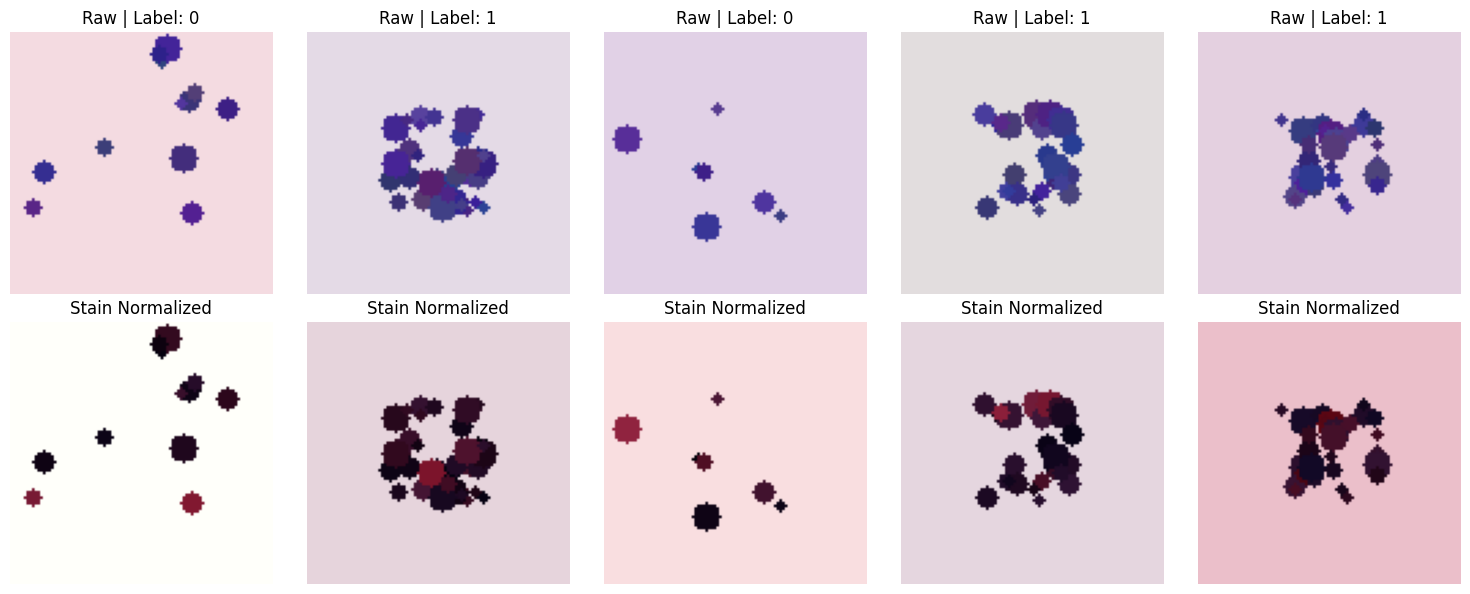

In [6]:
# --- CELL 5 ---
# Create a temporary dataset split without normalizations to see raw colors
viz_dataset = PatchCamelyonDataset(split='train', num_mock_samples=5)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    img_raw, label = viz_dataset[i]
    img_raw = viz_dataset.images[i] # raw numpy image
    img_normalized = normalize_stain_macenko(img_raw)

    # Show Raw
    axes[0, i].imshow(img_raw)
    axes[0, i].set_title(f"Raw | Label: {label}")
    axes[0, i].axis('off')

    # Show Stain Normalized
    axes[1, i].imshow(img_normalized)
    axes[1, i].set_title("Stain Normalized")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [7]:
# --- CELL 6 ---
# Load the pretrained ImageNet model
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Adapt final layer (classifier head) for binary classification
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

# Set Cross-Entropy loss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("Model Head:")
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 201MB/s]


Model Head:
Linear(in_features=512, out_features=2, bias=True)


In [8]:
# --- CELL 7 ---
num_epochs = 5
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("Starting training...")
for epoch in range(num_epochs):
    start_time = time.time()
    
    # ==================== TRAINING PHASE ====================
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).squeeze().long()
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct / total
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)
    
    # ==================== VALIDATION PHASE ====================
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).squeeze().long()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    epoch_val_loss = val_running_loss / len(val_dataset)
    epoch_val_acc = val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)
    
    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{num_epochs} ({elapsed:.1f}s) | "
          f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

print("Training Complete!")

Starting training...
Epoch 1/5 (79.6s) | Train Loss: 0.2485 Acc: 0.8980 | Val Loss: 0.6310 Acc: 0.7856
Epoch 2/5 (77.9s) | Train Loss: 0.1556 Acc: 0.9412 | Val Loss: 0.7376 Acc: 0.7570
Epoch 3/5 (78.7s) | Train Loss: 0.1260 Acc: 0.9534 | Val Loss: 0.9902 Acc: 0.7254
Epoch 4/5 (78.7s) | Train Loss: 0.1089 Acc: 0.9589 | Val Loss: 0.9095 Acc: 0.7501
Epoch 5/5 (78.7s) | Train Loss: 0.0998 Acc: 0.9638 | Val Loss: 0.8227 Acc: 0.7628
Training Complete!


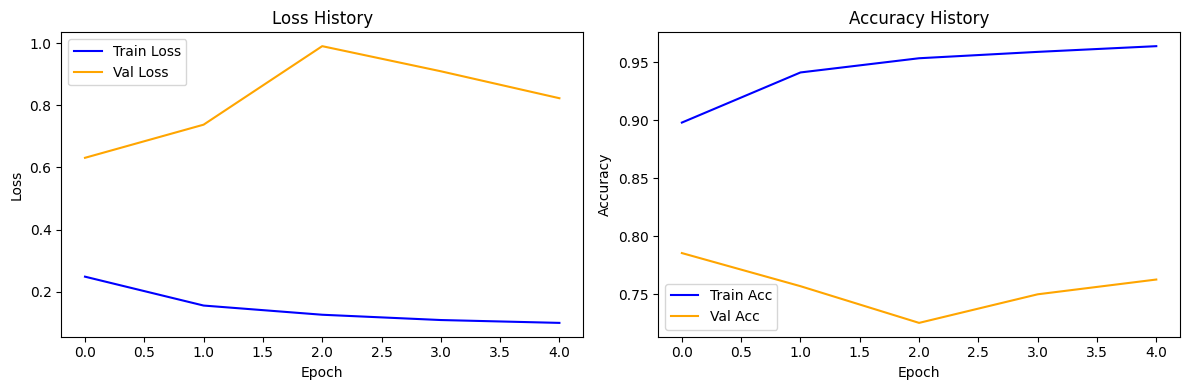

In [9]:
# --- CELL 8 ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Val Loss', color='orange')
plt.title('Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc', color='blue')
plt.plot(val_accs, label='Val Acc', color='orange')
plt.title('Accuracy History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
# --- CELL 9 ---
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Print metrics
print(f"Final Test Accuracy: {np.mean(all_preds == all_labels) * 100:.2f}%\n")
print(classification_report(all_labels, all_preds, target_names=['Healthy', 'Tumour']))

# Generate Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix / Caught-vs-Missed Table:")
print("------------------------------------------")
print(f"| True Negatives (Healthy correctly identified): {tn:<5} |")
print(f"| False Positives (Healthy called Tumour):       {fp:<5} |")
print(f"| False Negatives (Tumour MISSED!):              {fn:<5} |")
print(f"| True Positives (Tumour correctly caught):     {tp:<5} |")
print("------------------------------------------")

Final Test Accuracy: 76.28%

              precision    recall  f1-score   support

     Healthy       0.69      0.94      0.80     16391
      Tumour       0.90      0.59      0.71     16377

    accuracy                           0.76     32768
   macro avg       0.80      0.76      0.76     32768
weighted avg       0.80      0.76      0.76     32768

Confusion Matrix / Caught-vs-Missed Table:
------------------------------------------
| True Negatives (Healthy correctly identified): 15381 |
| False Positives (Healthy called Tumour):       1010  |
| False Negatives (Tumour MISSED!):              6763  |
| True Positives (Tumour correctly caught):     9614  |
------------------------------------------


Creating mock PatchCamelyon dataset (test split, 32768 samples)...


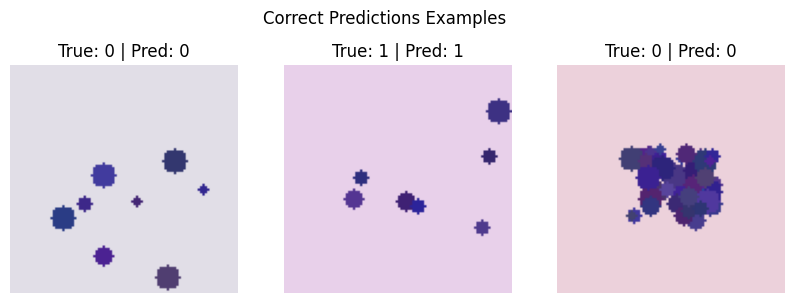

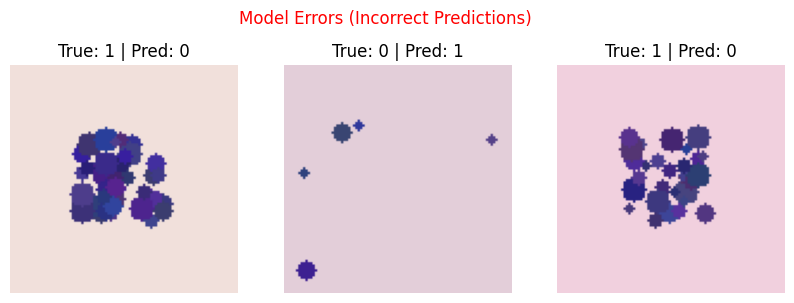

In [11]:
# --- CELL 10 ---
test_viz = PatchCamelyonDataset(split='test', num_mock_samples=len(test_dataset))
correct_idx = np.where(all_preds == all_labels)[0]
wrong_idx = np.where(all_preds != all_labels)[0]

# Visualize correct
if len(correct_idx) > 0:
    fig, axes = plt.subplots(1, min(3, len(correct_idx)), figsize=(10, 3.5))
    if min(3, len(correct_idx)) == 1: axes = [axes]
    fig.suptitle("Correct Predictions Examples", fontsize=12)
    for i in range(min(3, len(correct_idx))):
        idx = correct_idx[i]
        axes[i].imshow(test_viz.images[idx])
        axes[i].set_title(f"True: {all_labels[idx]} | Pred: {all_preds[idx]}")
        axes[i].axis('off')
    plt.show()

# Visualize wrong
if len(wrong_idx) > 0:
    fig, axes = plt.subplots(1, min(3, len(wrong_idx)), figsize=(10, 3.5))
    if min(3, len(wrong_idx)) == 1: axes = [axes]
    fig.suptitle("Model Errors (Incorrect Predictions)", fontsize=12, color='red')
    for i in range(min(3, len(wrong_idx))):
        idx = wrong_idx[i]
        axes[i].imshow(test_viz.images[idx])
        axes[i].set_title(f"True: {all_labels[idx]} | Pred: {all_preds[idx]}")
        axes[i].axis('off')
    plt.show()
else:
    print("Zero errors on the test split!")

In [15]:
# --- CELL 11: Single Image Inference ---
from PIL import Image

def analyze_single_slide(image_path, apply_stain_norm=True):
    # 1. Load the raw image
    raw_img = Image.open(image_path).convert('RGB')
    
    # 2. Apply Macenko stain normalization
    if apply_stain_norm:
        img_np = np.array(raw_img.resize((96, 96)))
        normalized_np = normalize_stain_macenko(img_np)
        processed_img = Image.fromarray(normalized_np)
    else:
        processed_img = raw_img.resize((96, 96))
        
    # 3. Apply standard PyTorch evaluation transforms
    inference_transform = transforms.Compose([
        transforms.Resize((96, 96)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    img_tensor = inference_transform(processed_img)
    
    # 4. Add batch dimension and move to GPU/device
    img_tensor = img_tensor.unsqueeze(0).to(device)
    
    # 5. Run prediction
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        prob_healthy = probabilities[0][0].item()
        prob_tumour = probabilities[0][1].item()
        
    # Determine prediction
    if prob_tumour > prob_healthy:
        prediction = "TUMOUR"
        confidence = prob_tumour * 100
    else:
        prediction = "HEALTHY"
        confidence = prob_healthy * 100
        
    # 6. Plot the original image and prediction
    plt.figure(figsize=(5, 5))
    plt.imshow(raw_img)
    plt.title(f"Prediction: {prediction} ({confidence:.2f}% Confidence)", 
              color='red' if prediction == "TUMOUR" else 'green', fontsize=14)
    plt.axis('off')
    plt.show()

    print(f"Diagnostics:")
    print(f" - Probability of Healthy tissue: {prob_healthy * 100:.2f}%")
    print(f" - Probability of Tumour tissue:  {prob_tumour * 100:.2f}%")

In [20]:
!rm -f /kaggle/working/custom_slide.png

Analyzing Slide Index: 125
True Label (Ground Truth): TUMOUR
----------------------------------------


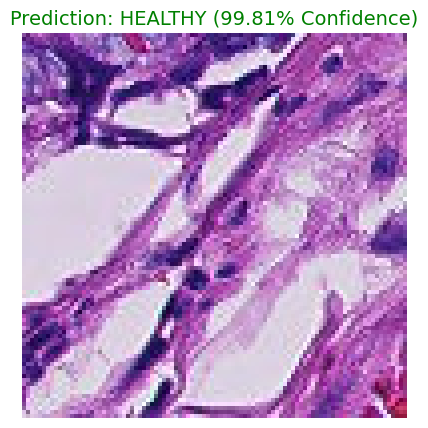

Diagnostics:
 - Probability of Healthy tissue: 99.81%
 - Probability of Tumour tissue:  0.19%


In [23]:
# Choose any index between 0 and 32767
slide_index = 125 

# Get the raw image and true label directly from your dataset
raw_img_array = test_dataset.x_data[slide_index]
true_label = int(test_dataset.y_data[slide_index].squeeze())

# Save it as a temporary image file on your Kaggle disk
from PIL import Image
temp_image_path = "/kaggle/working/temp_test_slide.png"
Image.fromarray(raw_img_array).save(temp_image_path)

# Run your inference function
print(f"Analyzing Slide Index: {slide_index}")
print(f"True Label (Ground Truth): {'TUMOUR' if true_label == 1 else 'HEALTHY'}")
print("-" * 40)

analyze_single_slide(temp_image_path, apply_stain_norm=True)

In [25]:
!pip install -q gradio


In [31]:
# --- CELL 13: Advanced & Simplified Pathology Dashboard ---
import gradio as gr
from PIL import Image
import numpy as np
import torch
from torchvision import transforms
import os

# 1. Prepare Example slide images from the Test set on disk
examples_list = []
for idx, name in [(42, "sample_healthy"), (120, "sample_tumour"), (250, "sample_borderline")]:
    raw_arr = test_dataset.x_data[idx]
    path = f"/kaggle/working/{name}.png"
    Image.fromarray(raw_arr).save(path)
    examples_list.append([path, True])

# 2. Advanced Diagnostic Logic with Custom HTML Rendering
def diagnose_and_render(img_input, apply_norm):
    if img_input is None:
        return (
            "<div style='text-align: center; color: #94a3b8; padding: 20px;'>⚠️ Please upload an image first.</div>",
            None
        )
        
    # Convert input to RGB
    raw_img = Image.fromarray(img_input.astype('uint8'), 'RGB')
    
    # 1. Stain Normalization
    if apply_norm:
        img_np = np.array(raw_img.resize((96, 96)))
        try:
            normalized_np = normalize_stain_macenko(img_np)
            processed_img = Image.fromarray(normalized_np)
        except:
            processed_img = raw_img.resize((96, 96))
            normalized_np = img_np
    else:
        processed_img = raw_img.resize((96, 96))
        normalized_np = np.array(processed_img)
        
    # 2. PyTorch Evaluation
    inference_transform = transforms.Compose([
        transforms.Resize((96, 96)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    img_tensor = inference_transform(processed_img).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        prob_healthy = probabilities[0][0].item()
        prob_tumour = probabilities[0][1].item()
        
    # 3. Render Custom HTML Verdict and glowing progress bars
    is_tumour = prob_tumour > prob_healthy
    verdict_color = "#ff4d4d" if is_tumour else "#2ecc71"
    verdict_bg = "#2a0808" if is_tumour else "#082013"
    verdict_text = "🚨 METASTASIS DETECTED" if is_tumour else "✅ NORMAL TISSUE"
    verdict_desc = "Active tumour cell clustering identified in the patch center." if is_tumour else "No significant metastatic clustering detected."

    html_output = f"""
    <div style="font-family: 'Inter', sans-serif; padding: 10px;">
        <!-- Verdict Banner -->
        <div style="background-color: {verdict_bg}; border: 2px solid {verdict_color}; border-radius: 12px; padding: 20px; text-align: center; margin-bottom: 20px; box-shadow: 0 0 15px {verdict_color}33;">
            <span style="color: {verdict_color}; font-size: 26px; font-weight: 800; display: block; letter-spacing: 1px; margin-bottom: 5px;">{verdict_text}</span>
            <span style="color: #94a3b8; font-size: 14px;">{verdict_desc}</span>
        </div>
        
        <!-- Diagnostic Probability Meters -->
        <div style="background-color: #111827; border: 1px solid #1f2937; border-radius: 12px; padding: 20px;">
            <h4 style="color: #f3f4f6; margin: 0 0 15px 0; font-size: 16px; font-weight: 600;">Diagnostic Analysis</h4>
            
            <!-- Tumour Probability Bar -->
            <div style="margin-bottom: 15px;">
                <div style="display: flex; justify-content: space-between; margin-bottom: 5px; font-size: 14px; font-weight: 500;">
                    <span style="color: #ef4444;">Tumour Probability</span>
                    <span style="color: #ef4444; font-weight: bold;">{prob_tumour * 100:.2f}%</span>
                </div>
                <div style="background-color: #1f2937; border-radius: 6px; height: 10px; overflow: hidden; width: 100%;">
                    <div style="background: linear-gradient(90deg, #c084fc, #ef4444); height: 100%; width: {prob_tumour * 100}%; border-radius: 6px; box-shadow: 0 0 8px #ef444488;"></div>
                </div>
            </div>
            
            <!-- Healthy Probability Bar -->
            <div>
                <div style="display: flex; justify-content: space-between; margin-bottom: 5px; font-size: 14px; font-weight: 500;">
                    <span style="color: #10b981;">Healthy Probability</span>
                    <span style="color: #10b981; font-weight: bold;">{prob_healthy * 100:.2f}%</span>
                </div>
                <div style="background-color: #1f2937; border-radius: 6px; height: 10px; overflow: hidden; width: 100%;">
                    <div style="background: linear-gradient(90deg, #6366f1, #10b981); height: 100%; width: {prob_healthy * 100}%; border-radius: 6px; box-shadow: 0 0 8px #10b98188;"></div>
                </div>
            </div>
        </div>
    </div>
    """
    return html_output, normalized_np

# 3. Custom Slate/Neon Theme setup
custom_theme = gr.themes.Soft(
    primary_hue="purple",
    secondary_hue="indigo",
    neutral_hue="slate"
).set(
    body_background_fill="*neutral_950",
    block_background_fill="*neutral_900",
    block_border_color="*neutral_800",
    button_primary_background_fill="*primary_600",
    button_primary_background_fill_hover="*primary_500"
)

# 4. Constructing clean blocks layout
with gr.Blocks(theme=custom_theme, title="RESNET HISTOPATHOLOGY") as demo:
    
    # Dashboard Header
    gr.HTML("""
    <div style="text-align: center; padding: 25px 0 15px 0; border-bottom: 1px solid #1f2937; margin-bottom: 25px;">
        <h1 style="color: #c084fc; font-size: 32px; font-weight: 800; margin: 0; letter-spacing: 0.5px;">🔬 CAD-Pathology Assistant</h1>
        <p style="color: #94a3b8; font-size: 16px; margin: 6px 0 0 0;">Interactive Deep-Learning Screening for Metastatic Lymph Nodes</p>
    </div>
    """)
    
    with gr.Row(equal_height=True):
        # Column 1: Input Control Panel
        with gr.Column(scale=1):
            gr.Markdown("### 📥 Step 1: Upload Tissue Patch")
            img_upload = gr.Image(label="Drag & Drop H&E slide image here", type="numpy", height=300)
            
            # Simple Settings
            stain_normalization_toggle = gr.Checkbox(label="Apply Macenko Stain Normalization", value=True)
            
            # Action Buttons
            with gr.Row():
                clear_btn = gr.Button("Clear", variant="secondary")
                submit_btn = gr.Button("Run Diagnostic", variant="primary")

        # Column 2: Dashboard Outputs
        with gr.Column(scale=1):
            gr.Markdown("### 📊 Step 2: Diagnostic Dashboard")
            
            # Custom HTML display for verdict and probability meters
            verdict_panel = gr.HTML("<div style='text-align: center; color: #64748b; padding: 40px 0;'>Upload a slide patch and click 'Run Diagnostic' to begin.</div>")
            
            # Stain Normalized image preview
            img_normalized_preview = gr.Image(label="Normalized Image Preview", interactive=False, height=200)

    # Clickable Examples Row
    gr.Markdown("### 💡 Click any slide to try immediately:")
    gr.Examples(
        examples=examples_list,
        inputs=[img_upload, stain_normalization_toggle],
        outputs=[verdict_panel, img_normalized_preview],
        fn=diagnose_and_render,
        cache_examples=True
    )
    
    # Event mappings
    submit_btn.click(
        fn=diagnose_and_render,
        inputs=[img_upload, stain_normalization_toggle],
        outputs=[verdict_panel, img_normalized_preview]
    )
    
    # Reset button map
    def clear_inputs():
        return None, True, "<div style='text-align: center; color: #64748b; padding: 40px 0;'>Upload a slide patch and click 'Run Diagnostic' to begin.</div>", None
        
    clear_btn.click(
        fn=clear_inputs,
        inputs=[],
        outputs=[img_upload, stain_normalization_toggle, verdict_panel, img_normalized_preview]
    )

    # Medical Disclaimer Footer
    gr.HTML("""
    <div style="text-align: center; margin-top: 40px; padding-top: 15px; border-top: 1px solid #1f2937; color: #4b5563; font-size: 12px; font-weight: 500;">
        ⚠️ <strong>Medical Disclaimer:</strong> This application is a research prototype for screening simulation. It is not an FDA-cleared diagnostic device.
    </div>
    """)

# Launch dashboard
demo.launch(share=True)

/tmp/ipykernel_58/1761931113.py:116: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=custom_theme, title="RESNET HISTOPATHOLOGY") as demo:


* Running on local URL:  http://127.0.0.1:7865
Caching examples at: '/kaggle/working/.gradio/cached_examples/136'


/tmp/ipykernel_58/1761931113.py:26: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  raw_img = Image.fromarray(img_input.astype('uint8'), 'RGB')
/tmp/ipykernel_58/1761931113.py:26: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  raw_img = Image.fromarray(img_input.astype('uint8'), 'RGB')
/tmp/ipykernel_58/1761931113.py:26: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  raw_img = Image.fromarray(img_input.astype('uint8'), 'RGB')


* Running on public URL: https://c11490bf9669975890.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
